In [178]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [179]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings("ignore")

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Time Series
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Set plotting style
sns.set_style("whitegrid")

In [180]:
# Load dataset
df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

# Display first 5 rows
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [181]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Dataset info
print("\nDataset Info:")
df.info()

Dataset Shape: (2640, 12)

Columns:
 Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float6

In [182]:
# Missing values
missing_values = df.isnull().sum()

print(missing_values)

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [183]:
# Statistical summary
df.describe(include='all')

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
count,2640.000000,2640.000000,2640,2640,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640,2640.000000
unique,NaN,NaN,4,5,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,Europe,Model S,NaN,NaN,NaN,NaN,NaN,NaN,Interpolated (Month),NaN
freq,NaN,NaN,660,528,NaN,NaN,NaN,NaN,NaN,NaN,884,NaN
mean,2020.000000,6.500000,NaN,NaN,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,NaN,8932.133712
std,3.162877,3.452707,NaN,NaN,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,NaN,3469.565883
min,2015.000000,1.000000,NaN,NaN,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,NaN,3002.000000
25%,2017.000000,3.750000,NaN,NaN,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,NaN,5897.750000
50%,2020.000000,6.500000,NaN,NaN,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,NaN,8901.500000
75%,2023.000000,9.250000,NaN,NaN,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,NaN,11938.000000


In [184]:
# Statistical summary
df.describe(include='all')

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
count,2640.000000,2640.000000,2640,2640,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640,2640.000000
unique,NaN,NaN,4,5,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,Europe,Model S,NaN,NaN,NaN,NaN,NaN,NaN,Interpolated (Month),NaN
freq,NaN,NaN,660,528,NaN,NaN,NaN,NaN,NaN,NaN,884,NaN
mean,2020.000000,6.500000,NaN,NaN,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,NaN,8932.133712
std,3.162877,3.452707,NaN,NaN,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,NaN,3469.565883
min,2015.000000,1.000000,NaN,NaN,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,NaN,3002.000000
25%,2017.000000,3.750000,NaN,NaN,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,NaN,5897.750000
50%,2020.000000,6.500000,NaN,NaN,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,NaN,8901.500000
75%,2023.000000,9.250000,NaN,NaN,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,NaN,11938.000000


In [185]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Check duplicates removed
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (2640, 12)


In [186]:
# Check columns
print(df.columns)

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')


In [187]:
# Create Date column from Year and Month

df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01'
)

# Create Quarter feature
df['Quarter'] = df['Date'].dt.quarter

# Verify
df[['Year', 'Month', 'Date', 'Quarter']].head()

,Year,Month,Date,Quarter
0,2023,5,2023-05-01,2
1,2015,2,2015-02-01,1
2,2019,1,2019-01-01,1
3,2021,2,2021-02-01,1
4,2016,12,2016-12-01,4


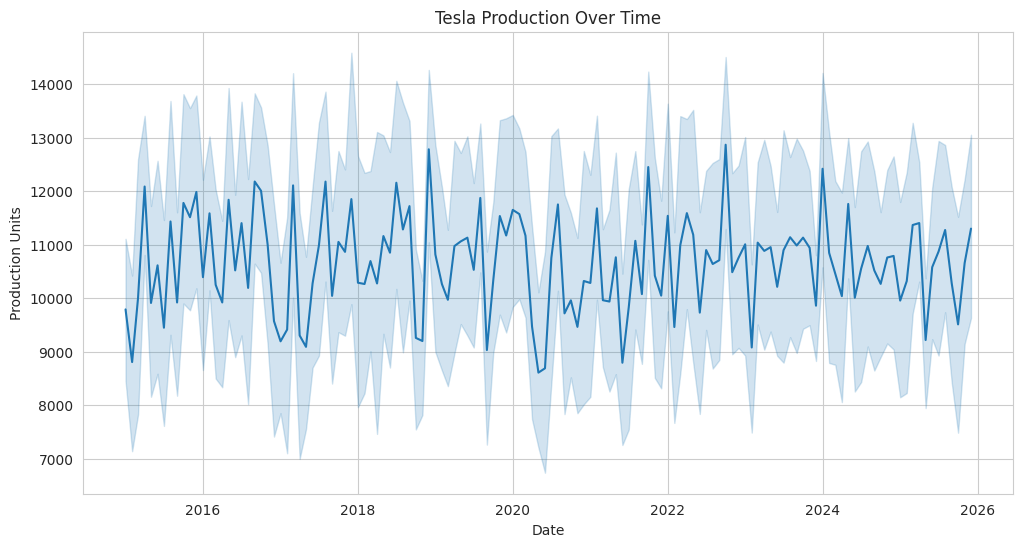

In [188]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x='Date',
    y='Production_Units',
    data=df
)

plt.title("Tesla Production Over Time")
plt.xlabel("Date")
plt.ylabel("Production Units")

plt.show()

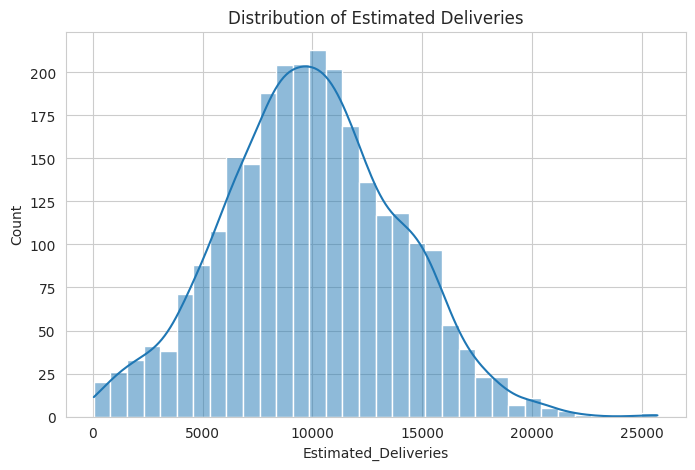

In [189]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Estimated_Deliveries'],
    kde=True
)

plt.title("Distribution of Estimated Deliveries")

plt.show()

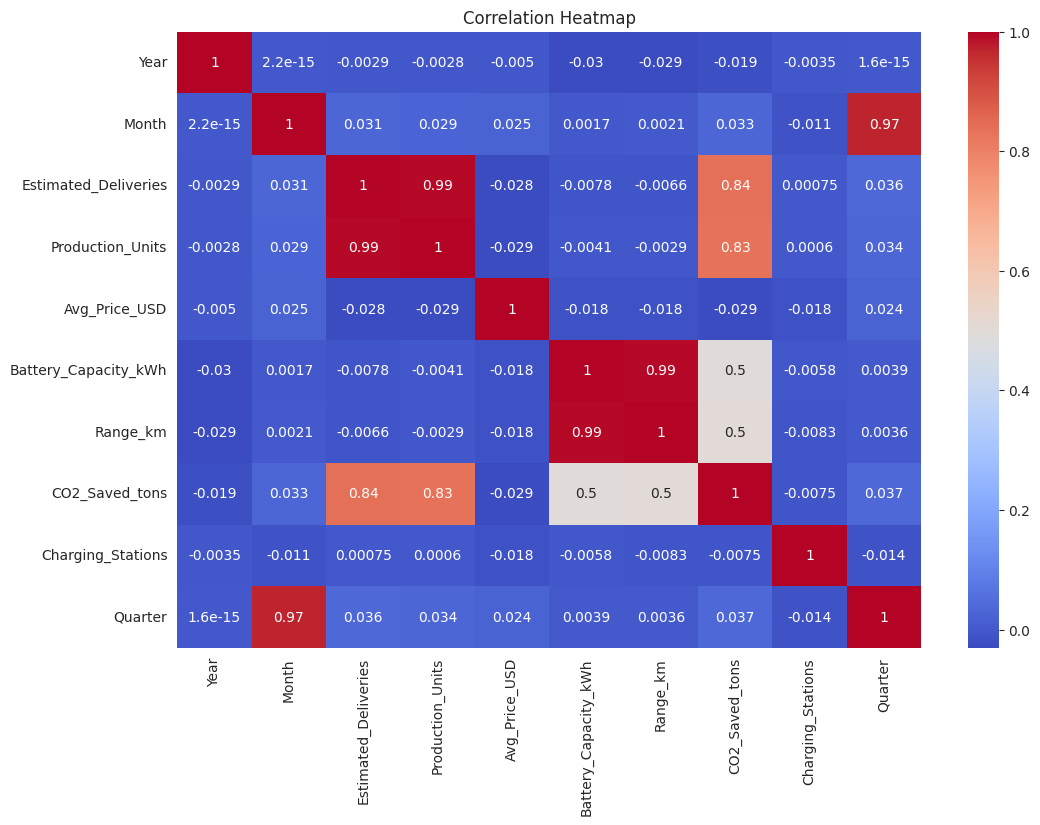

In [190]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

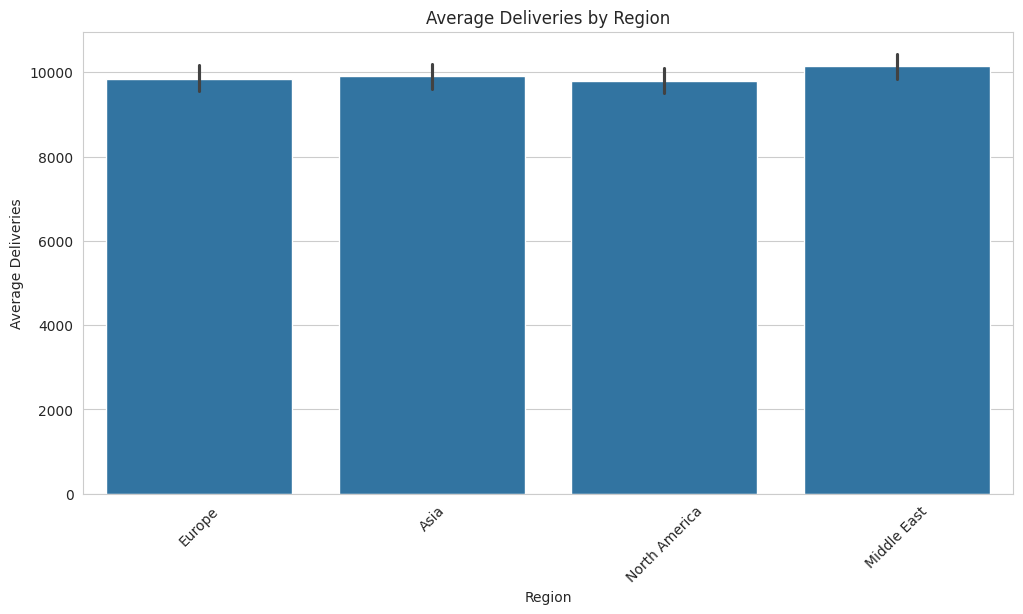

In [191]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Region',
    y='Estimated_Deliveries',
    data=df,
    estimator=np.mean
)

plt.title("Average Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Average Deliveries")

plt.xticks(rotation=45)

plt.show()

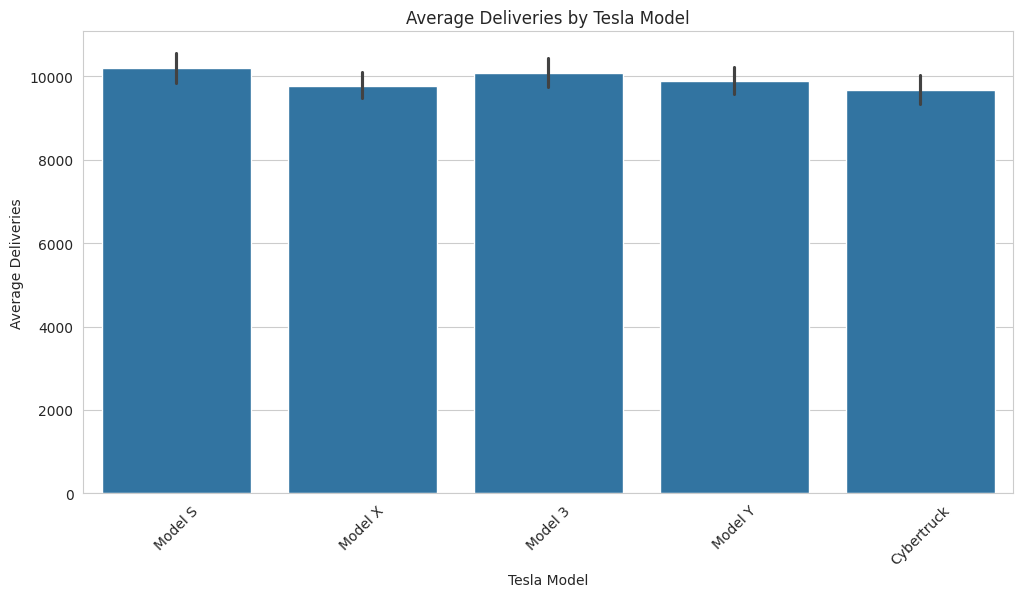

In [192]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='Estimated_Deliveries',
    data=df,
    estimator=np.mean
)

plt.title("Average Deliveries by Tesla Model")
plt.xlabel("Tesla Model")
plt.ylabel("Average Deliveries")

plt.xticks(rotation=45)

plt.show()

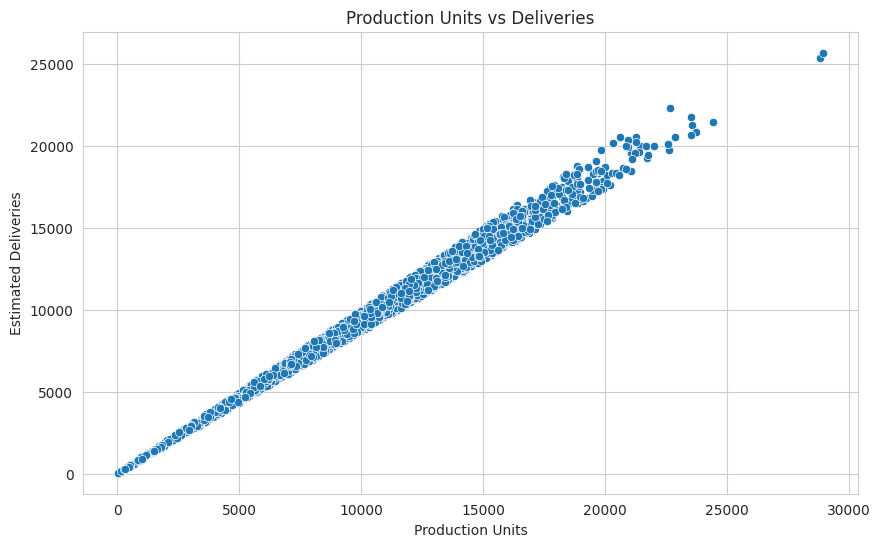

In [193]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Production_Units',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Production Units vs Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")

plt.show()

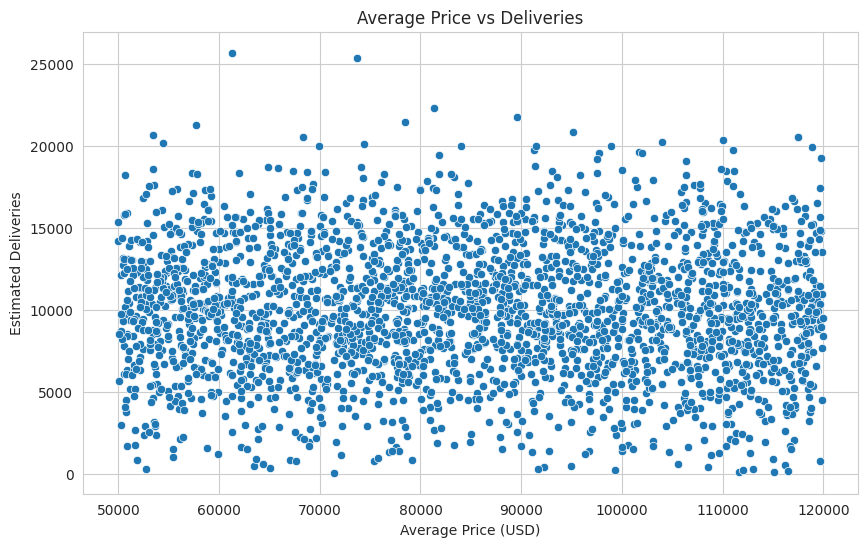

In [194]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Avg_Price_USD',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Average Price vs Deliveries")
plt.xlabel("Average Price (USD)")
plt.ylabel("Estimated Deliveries")

plt.show()

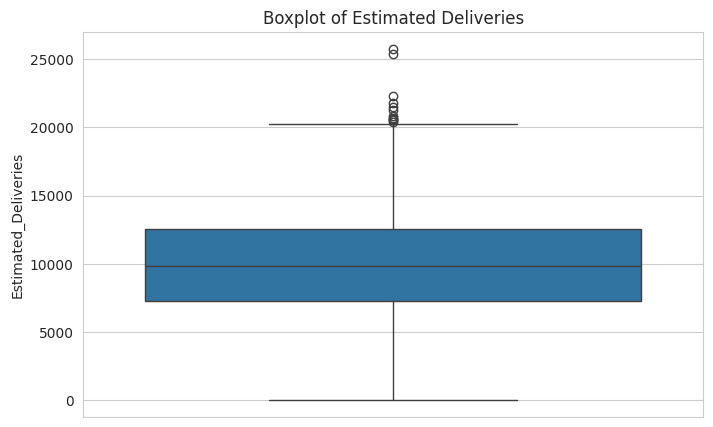

In [195]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df['Estimated_Deliveries']
)

plt.title("Boxplot of Estimated Deliveries")

plt.show()

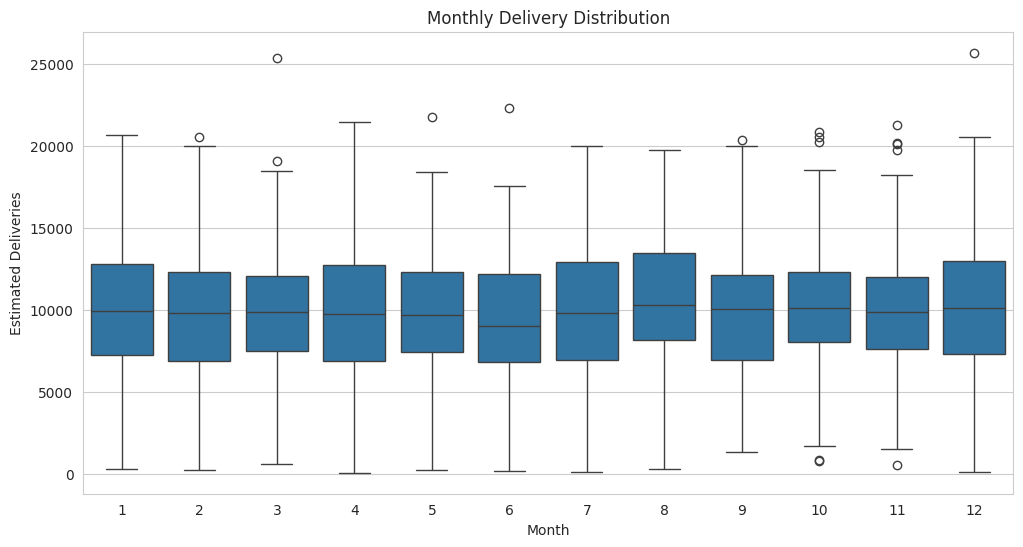

In [196]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='Month',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Monthly Delivery Distribution")
plt.xlabel("Month")
plt.ylabel("Estimated Deliveries")

plt.show()

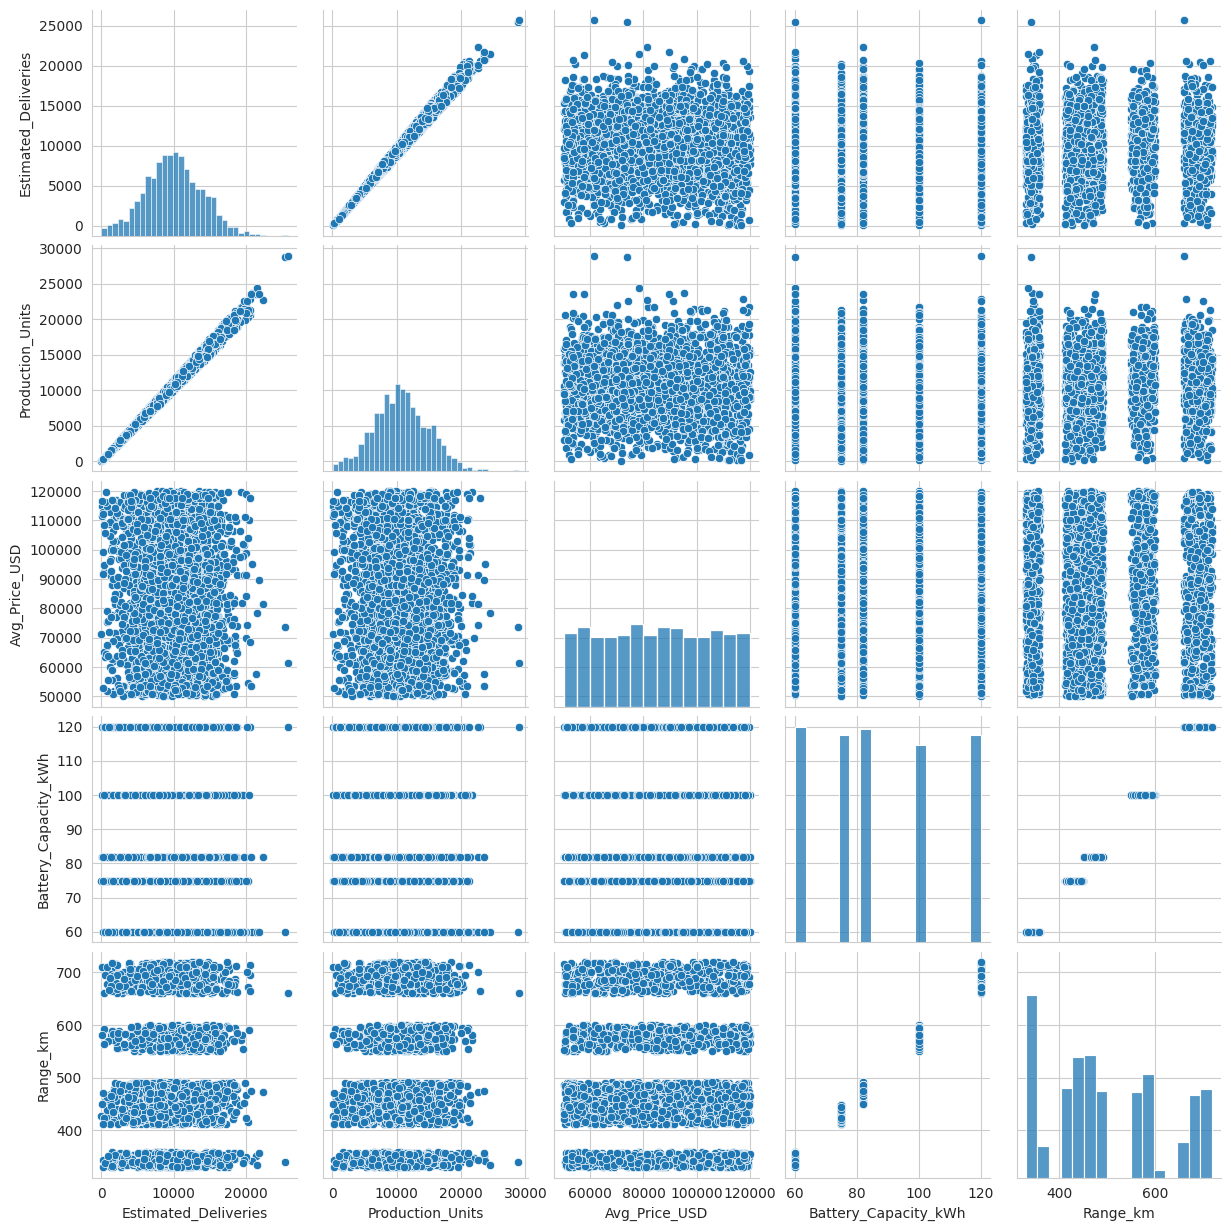

In [197]:
selected_cols = [
    'Estimated_Deliveries',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km'
]

sns.pairplot(df[selected_cols])

plt.show()

In [198]:
# Lag feature
df['Prev_Month_Delivery'] = df['Estimated_Deliveries'].shift(1)

# Rolling average
df['Rolling_Mean_4'] = (
    df['Estimated_Deliveries']
    .rolling(window=4)
    .mean()
)

# Drop NA values
df.dropna(inplace=True)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Prev_Month_Delivery,Rolling_Mean_4
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,1,8411.0,9102.25
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,4,6555.0,7784.25
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798,2020-04-01,2,12374.0,7999.00
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961,2015-11-01,4,4656.0,7825.50
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216,2020-06-01,2,7717.0,8289.25


In [199]:
# Features
X = df[[
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations',
    'Year',
    'Month',
    'Quarter',
    'Prev_Month_Delivery',
    'Rolling_Mean_4'
]]

# Target
y = df['Estimated_Deliveries']

print(X.head())

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   
5              5043       86930.57                    82       477   
6              7976       87588.21                    82       475   
7              9192       73815.61                   100       592   

   CO2_Saved_tons  Charging_Stations  Year  Month  Quarter  \
3          700.07               9333  2021      2        1   
4         1226.88               8722  2016     12        4   
5          333.14               5798  2020      4        2   
6          549.84               9961  2015     11        4   
7          746.81               8216  2020      6        2   

   Prev_Month_Delivery  Rolling_Mean_4  
3               8411.0         9102.25  
4               6555.0         7784.25  
5              12374.0         7999.00  
6               4656.0         7825.50  
7

In [200]:
# Aggregate deliveries by month

monthly_df = (
    df.groupby('Date')['Estimated_Deliveries']
    .sum()
    .reset_index()
)

monthly_df.head()

,Date,Estimated_Deliveries
0,2015-01-01,183180
1,2015-02-01,161256
2,2015-03-01,184567
3,2015-04-01,225623
4,2015-05-01,184264


In [201]:
monthly_df.set_index('Date', inplace=True)

monthly_df.head()

,Estimated_Deliveries
Date,
2015-01-01,183180
2015-02-01,161256
2015-03-01,184567
2015-04-01,225623
2015-05-01,184264


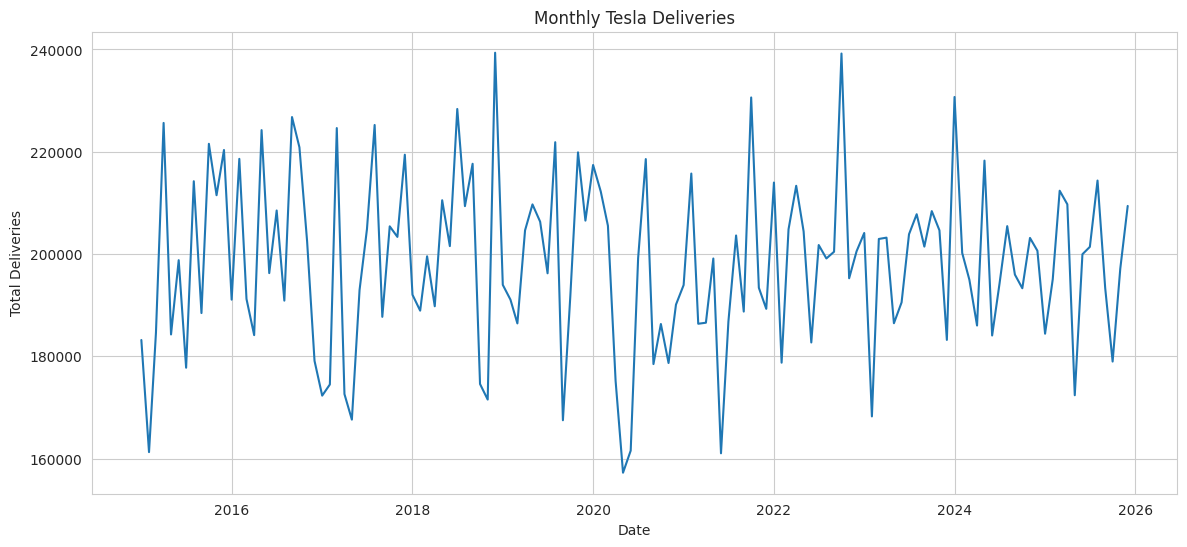

In [202]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_df.index,
    monthly_df['Estimated_Deliveries']
)

plt.title("Monthly Tesla Deliveries")
plt.xlabel("Date")
plt.ylabel("Total Deliveries")

plt.show()

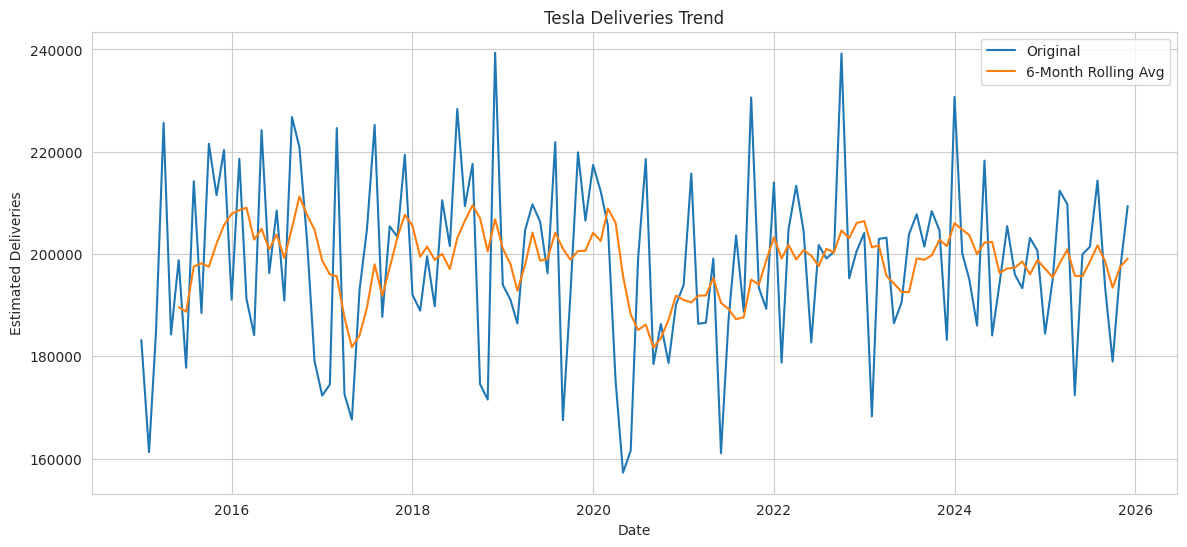

In [203]:
monthly_df['Rolling_Avg'] = (
    monthly_df['Estimated_Deliveries']
    .rolling(window=6)
    .mean()
)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_df.index,
    monthly_df['Estimated_Deliveries'],
    label='Original'
)

plt.plot(
    monthly_df.index,
    monthly_df['Rolling_Avg'],
    label='6-Month Rolling Avg'
)

plt.title("Tesla Deliveries Trend")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.legend()

plt.show()

In [204]:
# Train-test split

train = monthly_df.iloc[:-12]
test = monthly_df.iloc[-12:]

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (120, 2)
Test Shape: (12, 2)


In [205]:
model = ExponentialSmoothing(
    train['Estimated_Deliveries'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

fit_model = model.fit()

In [206]:
predictions = fit_model.forecast(12)

predictions

2025-01-01    193394.597155
2025-02-01    190267.889162
2025-03-01    197409.058583
2025-04-01    189453.683230
2025-05-01    198171.413690
2025-06-01    190812.354850
2025-07-01    201013.831872
2025-08-01    208040.601240
2025-09-01    198109.561776
2025-10-01    204940.611452
2025-11-01    196193.193882
2025-12-01    206201.120264
Freq: MS, dtype: float64

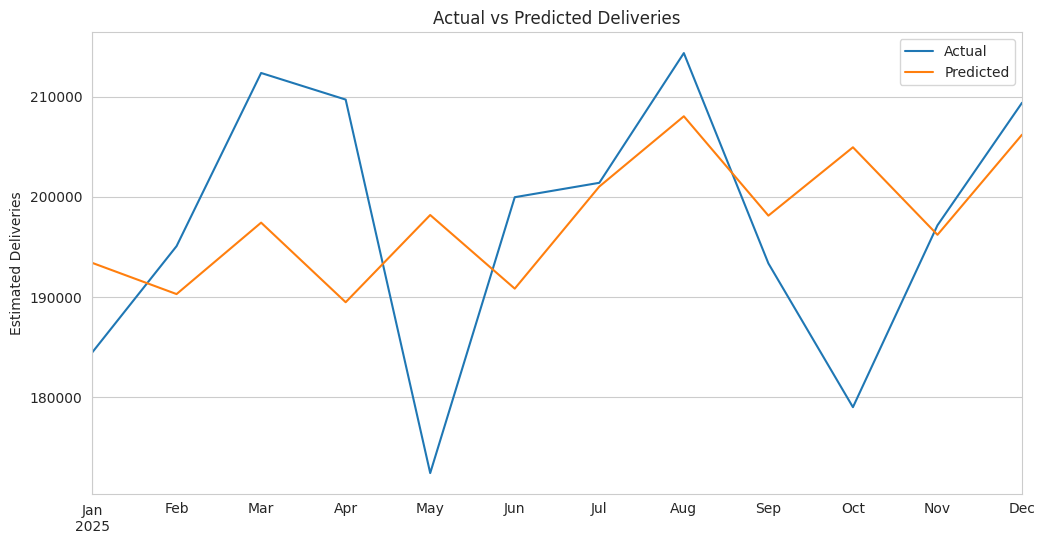

In [207]:
comparison_df = pd.DataFrame({
    'Actual': test['Estimated_Deliveries'],
    'Predicted': predictions
})

comparison_df.plot(
    figsize=(12,6)
)

plt.title("Actual vs Predicted Deliveries")
plt.ylabel("Estimated Deliveries")

plt.show()

In [208]:
# Forecast evaluation metrics

mae = mean_absolute_error(
    test['Estimated_Deliveries'],
    predictions
)

rmse = np.sqrt(mean_squared_error(
    test['Estimated_Deliveries'],
    predictions
))

print("Forecast MAE :", mae)
print("Forecast RMSE:", rmse)

#MAPE Calculation

mape = np.mean(
    np.abs(
        (test['Estimated_Deliveries'] - predictions)
        / test['Estimated_Deliveries']
    )
) * 100

print("Forecast MAPE: {:.2f}%".format(mape))

Forecast MAE : 10459.037582555398
Forecast RMSE: 13648.18847671413
Forecast MAPE: 5.47%


In [209]:
future_dates = test.index

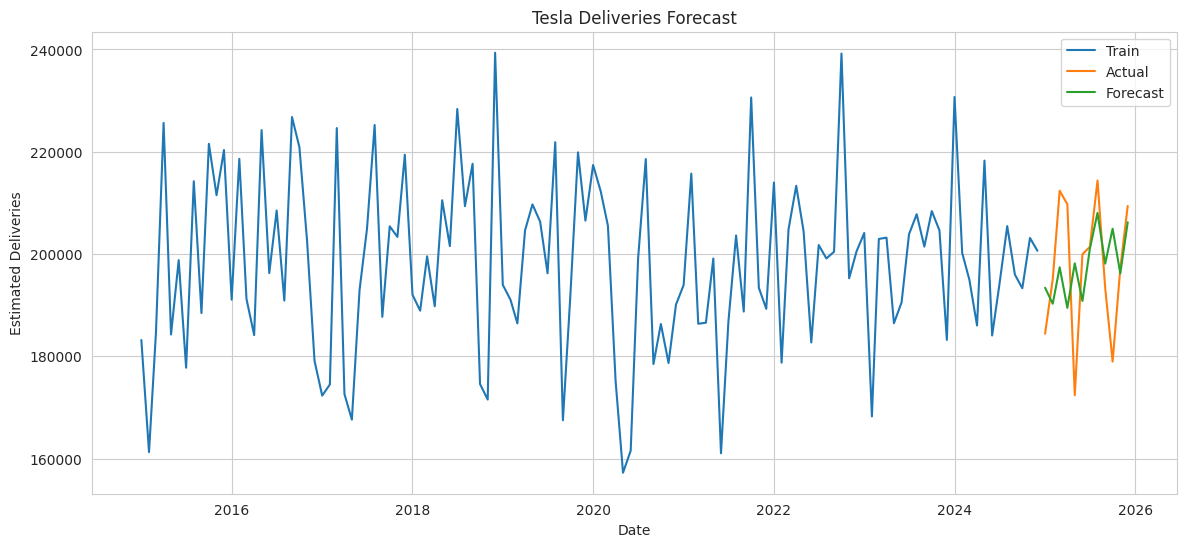

In [210]:
plt.figure(figsize=(14,6))

# Historical train data
plt.plot(
    train.index,
    train['Estimated_Deliveries'],
    label='Train'
)

# Actual test data
plt.plot(
    test.index,
    test['Estimated_Deliveries'],
    label='Actual'
)

# Forecast
plt.plot(
    future_dates,
    predictions,
    label='Forecast'
)

plt.title("Tesla Deliveries Forecast")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.legend()

plt.show()

## Final Forecasting Performance

The forecasting model achieved strong practical forecasting performance with a MAPE of 5.47%, indicating that predictions deviated by only ~5.5% on average from actual delivery values.

Although the R² score was negative due to high volatility and irregular fluctuations in the dataset, MAE, RMSE, and MAPE demonstrate that the model successfully captured the overall delivery trend and seasonal patterns.

This highlights the importance of using forecasting-specific evaluation metrics such as MAE, RMSE, and MAPE for time-series problems instead of relying solely on R².